## Ground Truth Generation

In [7]:
# %pip install networkx matplotlib graphviz pygraphviz

In [8]:
import random
import graphviz
import networkx as nx
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

import numpy as np

### DAG Generation

In [9]:
#min in-degree?
def generate_dag(
    n_nodes: int,
    max_in_degree: int,
    p_extra_edges: float = 0.0,
    seed: int | None = None
):
    rng = random.Random(seed)
    nodes = [f"X_{i}" for i in range(n_nodes)]

    # Random topological order
    order = nodes[:]
    rng.shuffle(order)
    position = {node: i for i, node in enumerate(order)}

    edges = []
    parents = {node: set() for node in nodes}

    # Backbone - Ensure weak connectivity
    for i in range(1, n_nodes):
        child = order[i]
        parent = rng.choice(order[:i])
        parents[child].add(parent)
        edges.append((parent, child))

    # Extra edges
    for child in order:
        possible_parents = [
            p for p in order[:position[child]]
            if p not in parents[child]
        ]
        rng.shuffle(possible_parents)
        for parent in possible_parents:
            if len(parents[child]) >= max_in_degree:
                break
            if rng.random() < p_extra_edges:
                parents[child].add(parent)
                edges.append((parent, child))

    return edges
 

### Ground Truth CPTs

In [10]:
# Dirichlet - i.i.d.

"""
rng = np.random.default_rng(seed)
n_configs = np.prod([cardinality[p] for p in parents])
values = rng.dirichlet([alpha] * card, size=n_configs).T   # shape (card, n_configs)

cpd = TabularCPD(variable=node, variable_card=card, values=values,
                 evidence=parents, evidence_card=[cardinality[p] for p in parents])
"""

'\nrng = np.random.default_rng(seed)\nn_configs = np.prod([cardinality[p] for p in parents])\nvalues = rng.dirichlet([alpha] * card, size=n_configs).T   # shape (card, n_configs)\n\ncpd = TabularCPD(variable=node, variable_card=card, values=values,\n                 evidence=parents, evidence_card=[cardinality[p] for p in parents])\n'

## Test

Edges: [('X_6', 'X_4'), ('X_6', 'X_7'), ('X_4', 'X_3'), ('X_6', 'X_5'), ('X_4', 'X_2'), ('X_7', 'X_0'), ('X_2', 'X_1'), ('X_4', 'X_7'), ('X_3', 'X_2'), ('X_6', 'X_2'), ('X_6', 'X_0'), ('X_3', 'X_1'), ('X_4', 'X_1')]
Number of edges: 13


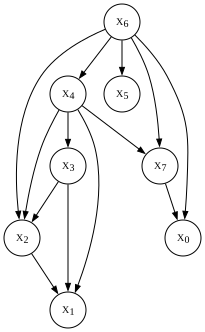

In [11]:
N_NODES = 8

edges = generate_dag(
    n_nodes=N_NODES,
    max_in_degree=3,
    p_extra_edges=0.2,
)

print(f"Edges: {edges}")
print(f"Number of edges: {len(edges)}")

dot = graphviz.Digraph(
    graph_attr={"rankdir": "TB"},
    node_attr={"width": "0.5", "height": "0.5", "fontsize": "10"},
    edge_attr={"arrowsize": "0.7"},
)

for u, v in edges:
    dot.edge(u, v)

for i in range(N_NODES):
    node_id = f"X_{i}"
    dot.node(node_id, label=f"<X<SUB>{i}</SUB>>")

dot